In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [3]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [9]:
# === Fig 4 overview, callable on scan output =========================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

def _plot_fig4(runs, FISH, ERAS, suptitle, spinup=15):
    SPINUP=spinup; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
    ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
    obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
    def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
    def ox(df,col='doy_hplc'):
        d=df[col] if col in df else pd.Series(np.nan,index=df.index)
        return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
    def _clim(r,k):
        keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
        v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
    def _vals(r,k):
        keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
        yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
        return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
    def _daily(r,k):
        keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
        for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
        return out
    def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
    def _bar(ax,x,vals,c,h=None,w=0.18):
        v=np.asarray(vals,float); v=v[np.isfinite(v)]
        if v.size==0: return
        lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
    fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
        ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
        for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
        om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
        ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
        ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
        for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
        ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
        ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
        allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
        ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
        ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
        if col.start==0: ax.legend(fontsize=7,frameon=False)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
        for cls,cc in CLS:
            for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
            o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
            ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
        ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
        ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
        if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
    BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
    W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
    for j,(title,metrics) in enumerate(BP):
        ax=fig.add_subplot(gs[3,j])
        for i,(lab,key) in enumerate(metrics):
            for era in ERAS:
                c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
                obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
                _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
        ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
        if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
    fig.suptitle(suptitle,fontsize=10); plt.show()

def fig4_overview(RP, RQ, rF_pre, rF_post, sel=None, construct='maranon_ward',
                  years=60, spinup=15, n_harmonics=3, routed=True, title=None):
    """Re-run + plot the Fig 4 overview for a (pre,post) pair from scan results RP (pre) / RQ (post).
    `sel` disambiguates the swept param, e.g. sel={'KsZ':0.15}. Construct params are taken from the
    PRE record (shared across eras); only r_F differs by era. Returns (runs, clims)."""
    ERAS=['pre+recovery','post']; FISH={'pre+recovery':rF_pre,'post':rF_post}
    spec=ssh.allometry(construct) if isinstance(construct,str) else construct
    def _find(R,f):
        for r in R.records:
            if abs(r['fish']-f)<1e-9 and all(abs(r.get(k,np.nan)-v)<1e-9 for k,v in (sel or {}).items()): return r
        raise ValueError(f"no record fish={f} sel={sel}")
    rec=_find(RP,rF_pre)                                   # shared construct -> reconstruct from pre
    ivo,mP,mZ={},None,None
    for k in RP.param_names:
        v=rec[k]
        if k=='mP': mP=v; continue
        if k=='m_Z': mZ=v; continue
        if k in ('mu_scale','graze_scale'): continue
        slot,key=ssh._PARAM_SLOT[k]; ivo.setdefault(slot,{})[key]=v
    runs,clims={},{}
    for era,f in FISH.items():
        print(f"\n##### {era}  r_F={f} #####"); ssh.describe_run(spec, RP.forcings[era], fish_rate=f,
            mP=mP, m_Z=mZ, iv_overrides=ivo, n_harmonics=n_harmonics, routed=routed)
        clim,r=ssh.run_one(spec, RP.forcings[era], fish_rate=f, mP=mP, m_Z=mZ, iv_overrides=ivo,
            years=years, spinup=spinup, n_harmonics=n_harmonics, routed=routed, return_traj=True)
        runs[era],clims[era]=r,clim
    OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; K5=['mcs','pico','nano','micro','sumP']; W={k:1. for k in K5}
    f5=lambda c,g: float(np.nanmax([ssh.score({k:c.get(k+'_med',np.nan) for k in K5},OBS[g]['med'],W),
                                    ssh.score({k:c.get(k,np.nan) for k in K5},OBS[g]['mean'],W)]))
    inv=clims['post']['Z200_med']-clims['pre+recovery']['Z200_med']
    print(f"\nfit5 pre {f5(clims['pre+recovery'],'pre+recovery'):.4f} | post {f5(clims['post'],'post'):.4f} "
          f"| inv {inv:+.4f} (obs {OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']:+.4f}) "
          f"| cv {clims['pre+recovery']['cv_sumP']:.2f}/{clims['post']['cv_sumP']:.2f} "
          f"| pze {clims['pre+recovery']['pze']:.2f}/{clims['post']['pze']:.2f}")
    _plot_fig4(runs, FISH, ERAS, title or f"{spec.get('name','?')} | sel={sel} | rF {rF_pre}/{rF_post}", spinup)
    return runs, clims

# --- examples (uses RP/RQ from the KsZ readout cell) ---
#runs,clims = fig4_overview(RP, RQ, 0.65, 0.10, sel={'KsZ':0.23})   # current baseline
#runs,clims = fig4_overview(RP, RQ, 0.50, 0.10, sel={'KsZ':0.15}) # lower & calmer pre candidate
#runs,clims = fig4_overview(RP, RQ, 0.40, 0.15, sel={'KsZ':0.15})

In [3]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF_PRE = [0.3, 0.4, 0.5, 0.55, 0.6, 0.65]
KSZ=[0.15,0.20,0.23]; GGE=[0.25,0.28,0.31,0.33]; SIG=[0.15,0.18,0.20,0.22,0.25]; MZ=[0.05,0.10]
DETR=[(5.0,0.04),(5.0,0.067),(7.5,0.04)]                       # (w_sink,k_remin) paired -> L 125/75/188
PIN=dict(mP=0.0015, fish_fX=0.25, fish_fD=0.25, zq_fD=0.90, zq_fX=0.0, zl_fD=0.90, zl_fX=0.0)
COMBOS=[dict(KsZ=k,GGE=g,sigma_log=s,m_Z=m,w_sink=ws,k_remin=kr,**PIN)
        for k in KSZ for g in GGE for s in SIG for m in MZ for (ws,kr) in DETR]   # 360 constructs
print(f"{len(COMBOS)} constructs x {len(RF_PRE)} r_F = {len(COMBOS)*len(RF_PRE)} pre runs")
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=RF_PRE,
    param_combos=COMBOS, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_grid2_pre_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res.records))

360 constructs x 6 r_F = 2160 pre runs
[seasonal scan] 2160 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.3, 0.4, 0.5, 0.55, 0.6, 0.65] x params['GGE', 'KsZ', 'fish_fD', 'fish_fX', 'k_remin', 'mP', 'm_Z', 'sigma_log', 'w_sink', 'zl_fD', 'zl_fX', 'zq_fD', 'zq_fX'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.15  Q10 2.48
  scalars : GGE 0.25  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.05  m_Zlin 0.05  r_F 0.3
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / ex

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1587 on Z[1] = -0.00146. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   53/2160 maranon_ward  pre+recovery  fish=0.3  {'KsZ': 0.15, 'GGE': 0.31, 'sigma_log': 0.18, 'm_Z': 0.05, 'w_sink': 5.0, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan |  4.8m ETA 191.2m


/Users/aoop/Documents/GitHub/SSMCariaco/parameter_scan/seasonal_scan_harness.py:374: RuntimeWarning: Mean of empty slice
  clim['NPP'] = float(np.nanmean(r['NPP'][_k])); clim['export_total'] = float(np.nanmean(r['ExportTotal'][_k]))


   54/2160 maranon_ward  pre+recovery  fish=0.3  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.22, 'm_Z': 0.05, 'w_sink': 5.0, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 6.03/ 2.70 micro=0.26 Z200pk=0.313 conv=1.02 nan=False score= 0.40 |  4.8m ETA 188.9m
   55/2160 maranon_ward  pre+recovery  fish=0.3  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.22, 'm_Z': 0.05, 'w_sink': 7.5, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 5.19/ 2.62 micro=0.25 Z200pk=0.151 conv=1.20 nan=False score= 0.40 |  5.0m ETA 189.5m
   56/2160 maranon_ward  pre+recovery  fish=0.3  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.22, 'm_Z': 0.1, 'w_sink': 7.5, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 5.53/ 3.10 micro=0.27 Z200pk=0.238 conv=0.98 nan=False score= 0.32 |  5.0m ETA 188

...

  399/2160 maranon_ward  pre+recovery  fish=0.4  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.18, 'm_Z': 0.1, 'w_sink': 5.0, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 30.9m ETA 136.3m
  400/2160 maranon_ward  pre+recovery  fish=0.4  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.18, 'm_Z': 0.05, 'w_sink': 7.5, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 7.74/ 3.17 micro=0.31 Z200pk=0.200 conv=1.03 nan=False score= 0.31 | 30.9m ETA 136.1m
  401/2160 maranon_ward  pre+recovery  fish=0.4  {'KsZ': 0.15, 'GGE': 0.28, 'sigma_log': 0.18, 'm_Z': 0.1, 'w_sink': 7.5, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 8.77/ 3.20 micro=0.33 Z200pk=0.138 conv=1.03 nan=False score= 0.30 | 30.9m ETA 135.8

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1948 on Z[1] = -0.00175. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  1522/2160 maranon_ward  pre+recovery  fish=0.6  {'KsZ': 0.15, 'GGE': 0.33, 'sigma_log': 0.18, 'm_Z': 0.05, 'w_sink': 5.0, 'k_remin': 0.067, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 116.0m ETA 48.6m


/Users/aoop/Documents/GitHub/SSMCariaco/parameter_scan/seasonal_scan_harness.py:374: RuntimeWarning: Mean of empty slice
  clim['NPP'] = float(np.nanmean(r['NPP'][_k])); clim['export_total'] = float(np.nanmean(r['ExportTotal'][_k]))


  1523/2160 maranon_ward  pre+recovery  fish=0.6  {'KsZ': 0.15, 'GGE': 0.31, 'sigma_log': 0.25, 'm_Z': 0.05, 'w_sink': 5.0, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 5.18/ 4.27 micro=0.34 Z200pk=0.091 conv=1.03 nan=False score= 0.25 | 116.0m ETA 48.5m
  1524/2160 maranon_ward  pre+recovery  fish=0.6  {'KsZ': 0.15, 'GGE': 0.31, 'sigma_log': 0.22, 'm_Z': 0.1, 'w_sink': 7.5, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 8.04/ 3.74 micro=0.33 Z200pk=0.181 conv=0.99 nan=False score= 0.22 | 116.1m ETA 48.5m
  1525/2160 maranon_ward  pre+recovery  fish=0.6  {'KsZ': 0.15, 'GGE': 0.31, 'sigma_log': 0.22, 'm_Z': 0.1, 'w_sink': 5.0, 'k_remin': 0.04, 'mP': 0.0015, 'fish_fX': 0.25, 'fish_fD': 0.25, 'zq_fD': 0.9, 'zq_fX': 0.0, 'zl_fD': 0.9, 'zl_fX': 0.0} mcs= 6.66/ 3.88 micro=0.33 Z200pk=0.143 conv=1.07 nan=False score= 0.20 | 116.1m ETA 

In [4]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF_POST = [0.1, 0.15, 0.2]
KSZ=[0.15,0.20,0.23]; GGE=[0.25,0.28,0.31,0.33]; SIG=[0.15,0.18,0.20,0.22,0.25]; MZ=[0.05,0.10]
DETR=[(5.0,0.04),(5.0,0.067),(7.5,0.04)]
PIN=dict(mP=0.0015, fish_fX=0.25, fish_fD=0.25, zq_fD=0.90, zq_fX=0.0, zl_fD=0.90, zl_fX=0.0)
COMBOS=[dict(KsZ=k,GGE=g,sigma_log=s,m_Z=m,w_sink=ws,k_remin=kr,**PIN)
        for k in KSZ for g in GGE for s in SIG for m in MZ for (ws,kr) in DETR]
print(f"{len(COMBOS)} constructs x {len(RF_POST)} r_F = {len(COMBOS)*len(RF_POST)} post runs")
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=RF_POST,
    param_combos=COMBOS, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_grid2_post_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('post done:', len(res.records))

360 constructs x 3 r_F = 1080 post runs
[seasonal scan] 1080 runs: ['maranon_ward'] x ['post'] x fish=[0.1, 0.15, 0.2] x params['GGE', 'KsZ', 'fish_fD', 'fish_fX', 'k_remin', 'mP', 'm_Z', 'sigma_log', 'w_sink', 'zl_fD', 'zl_fX', 'zq_fD', 'zq_fX'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.15  Q10 2.48
  scalars : GGE 0.25  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.05  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish    

In [6]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
from collections import defaultdict
RP=ssh.load_results('seasonal_grid2_pre_2026-06-29.pkl'); RQ=ssh.load_results('seasonal_grid2_post_2026-06-29.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; obs_m=ssh.build_obs_monthly(['pre+recovery','post']); _MO=np.arange(1,13)
log_oc={g:np.log10(obs_m[g].dropna(subset=['mcs']).groupby('mo')['mcs'].median().reindex(_MO).to_numpy()) for g in OBS}
oP,oQ=OBS['pre+recovery']['med'],OBS['post']['med']; CK=['KsZ','GGE','sigma_log','m_Z','w_sink','k_remin']
SQ_THR, SHP_TOL, SHN_TOL = 0.30, 0.15, 0.25; ZMIN_INV, ZPRE_FLOOR, ZRAT_MAX = 0.002, 0.008, 2.0
def ck(r): return tuple(round(r[k],4) for k in CK)
def comp_e(r,o):
    ks=['mcs','pico','nano','micro']; e=[(r.get(k+'_med',np.nan)-o[k])/o[k] for k in ks if o.get(k)]
    return float(np.sqrt(np.nanmean(np.square(e))))
def brmse(r,g):
    c=np.asarray(r.get('clim_mcs',[np.nan]*12),float); return float(np.sqrt(np.nanmean((np.log10(c)-log_oc[g])**2)))
def rs(a,b): return (a-b)/a if abs(a)>1e-9 else np.nan
Qby=defaultdict(list)
for q in RQ.records: Qby[ck(q)].append(q)
rows=[]
for p in RP.records:
    if p.get('has_nan'): continue
    for q in Qby.get(ck(p),[]):
        if q.get('has_nan') or q['fish']>p['fish']+1e-9: continue
        comp=max(comp_e(p,oP),comp_e(q,oQ)); bl=max(brmse(p,'pre+recovery'),brmse(q,'post'))
        inv=q['Z200_med']-p['Z200_med']; Zrat=q['Z200_med']/max(p['Z200_med'],1e-9)
        shP=abs(rs(p['sumP_med'],q['sumP_med'])-rs(oP['sumP'],oQ['sumP'])); shN=abs(rs(p['N_med'],q['N_med'])-rs(oP['N'],oQ['N']))
        sqg=p.get('squiggle_sumP',np.nan); row={k:round(p[k],3) for k in CK}
        row.update(rFpre=round(p['fish'],2),rFpost=round(q['fish'],2), comp=round(comp,3), bloom=round(bl,3),
            inv=round(inv,4), Zrat=round(Zrat,2), squig=round(sqg,3), shP=round(shP,3), shN=round(shN,3),
            pze=round(p.get('pze',np.nan),2), cvPre=round(p['cv_sumP'],2),
            Z_ok=bool(inv>=ZMIN_INV and p['Z200_med']>=ZPRE_FLOOR and Zrat<=ZRAT_MAX),
            shP_ok=bool(shP<=SHP_TOL), sq_ok=bool(sqg<=SQ_THR), shN_ok=bool(shN<=SHN_TOL))
        rows.append(row)
X=pd.DataFrame(rows)
cols=CK+['rFpre','rFpost','comp','bloom','inv','squig','shP','shN','pze','cvPre','Z_ok','shP_ok','sq_ok','shN_ok']
hard = X['Z_ok'] & X['shP_ok']                       # HARD: real cascade + ΣP shift; squiggle & N-shift soft
print(f"OBS relshift sumP {rs(oP['sumP'],oQ['sumP']):.2f} N {rs(oP['N'],oQ['N']):.2f} | {len(X)} pairs | "
      f"Z_ok {int(X['Z_ok'].sum())} shP_ok {int(X['shP_ok'].sum())} sq_ok {int(X['sq_ok'].sum())} shN_ok {int(X['shN_ok'].sum())} | hard {int(hard.sum())}")
print("\n=== HARD (cascade + ΣP-shift) ranked by comp; squiggle & shN soft/reported ===")
print(X[hard].sort_values('comp')[cols].head(25).to_string(index=False) if hard.any() else "  none")
print("\n=== strict all-4 (incl. soft squiggle+shN) by comp — expect few/none ===")
a=hard & X['sq_ok'] & X['shN_ok']
print(X[a].sort_values('comp')[cols].head(15).to_string(index=False) if a.any() else "  none — the clean↔cascade tension; squiggle/shN are the soft ones to relax")

OBS relshift sumP 0.17 N 0.25 | 6471 pairs | Z_ok 1307 shP_ok 5825 sq_ok 2298 shN_ok 2060 | hard 1198

=== HARD (cascade + ΣP-shift) ranked by comp; squiggle & shN soft/reported ===
 KsZ  GGE  sigma_log  m_Z  w_sink  k_remin  rFpre  rFpost  comp  bloom    inv  squig   shP   shN  pze  cvPre  Z_ok  shP_ok  sq_ok  shN_ok
0.15 0.25       0.20 0.10     5.0    0.067   0.55    0.10 0.078  0.460 0.0042  0.494 0.149 0.119 0.49   1.35  True    True  False    True
0.15 0.25       0.20 0.05     5.0    0.067   0.60    0.15 0.092  0.462 0.0086  0.688 0.113 0.060 0.48   1.37  True    True  False    True
0.15 0.28       0.20 0.10     5.0    0.067   0.65    0.20 0.102  0.477 0.0055  0.438 0.140 0.152 0.48   1.38  True    True  False    True
0.15 0.28       0.20 0.10     5.0    0.067   0.65    0.10 0.102  0.497 0.0148  0.438 0.100 0.132 0.48   1.38  True    True  False    True
0.15 0.25       0.20 0.05     5.0    0.067   0.65    0.15 0.111  0.462 0.0061  0.625 0.116 0.182 0.49   1.40  True    True  Fals

In [11]:
import numpy as np, seasonal_scan_harness as ssh
def _squiggle(r, key, spinup=15):
    keep=r['t']>=spinup*365.0; t=r['t'][keep]; v=np.asarray(r[key],float)[keep]
    yr=(t//365).astype(int); mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    ys=np.unique(yr); M=np.full((len(ys),12),np.nan)
    for i,y in enumerate(ys):
        for m in range(1,13):
            sel=v[(yr==y)&(mo==m)]
            if sel.size: M[i,m-1]=np.nanmean(sel)
    return float(np.nanmean(np.nanstd(M,axis=0))/max(np.nanmean(v),1e-9))
def squiggle_report(runs, spinup=15):
    for g,r in runs.items():
        print(f"{g:14s} squiggle  ΣP {_squiggle(r,'sumP',spinup):.3f}   micro {_squiggle(r,'micro',spinup):.3f}   (HIGH = spaghetti)")


##### pre+recovery  r_F=0.55 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.25  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.55
  detritus: k_remin 0.067  w_sink 5.0  ->  L = 75 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.25 / export 0.25
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

##### post  r_F=0.1 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-1

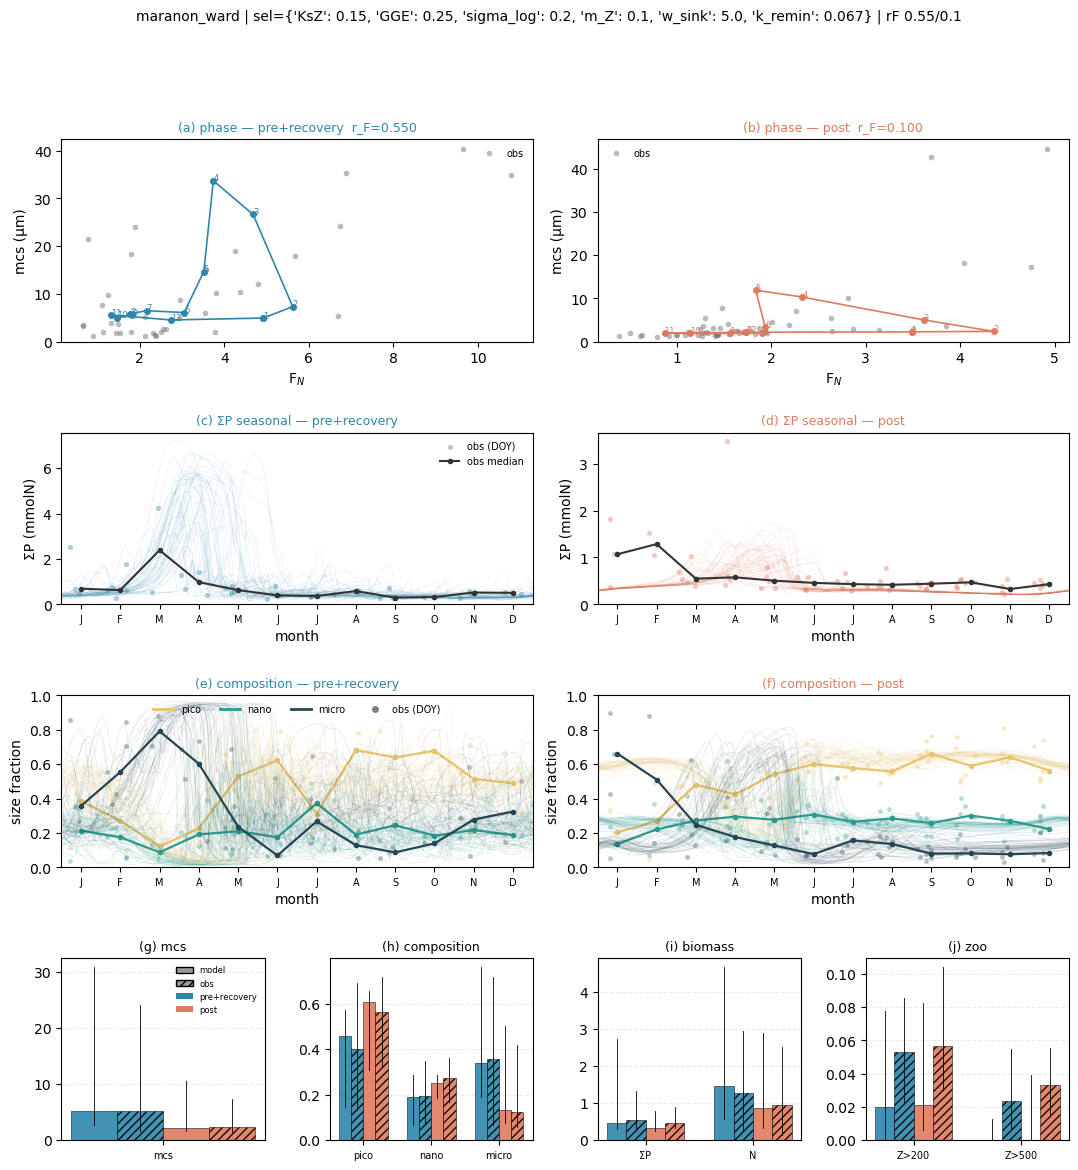

pre+recovery   squiggle  ΣP 0.495   micro 0.361   (HIGH = spaghetti)
post           squiggle  ΣP 0.175   micro 0.368   (HIGH = spaghetti)

##### pre+recovery  r_F=0.65 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.2  sigma_log 0.22  Q10 2.48
  scalars : GGE 0.28  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.05  m_Zlin 0.05  r_F 0.65
  detritus: k_remin 0.067  w_sink 5.0  ->  L = 75 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.25 / export 0.25
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

##### po

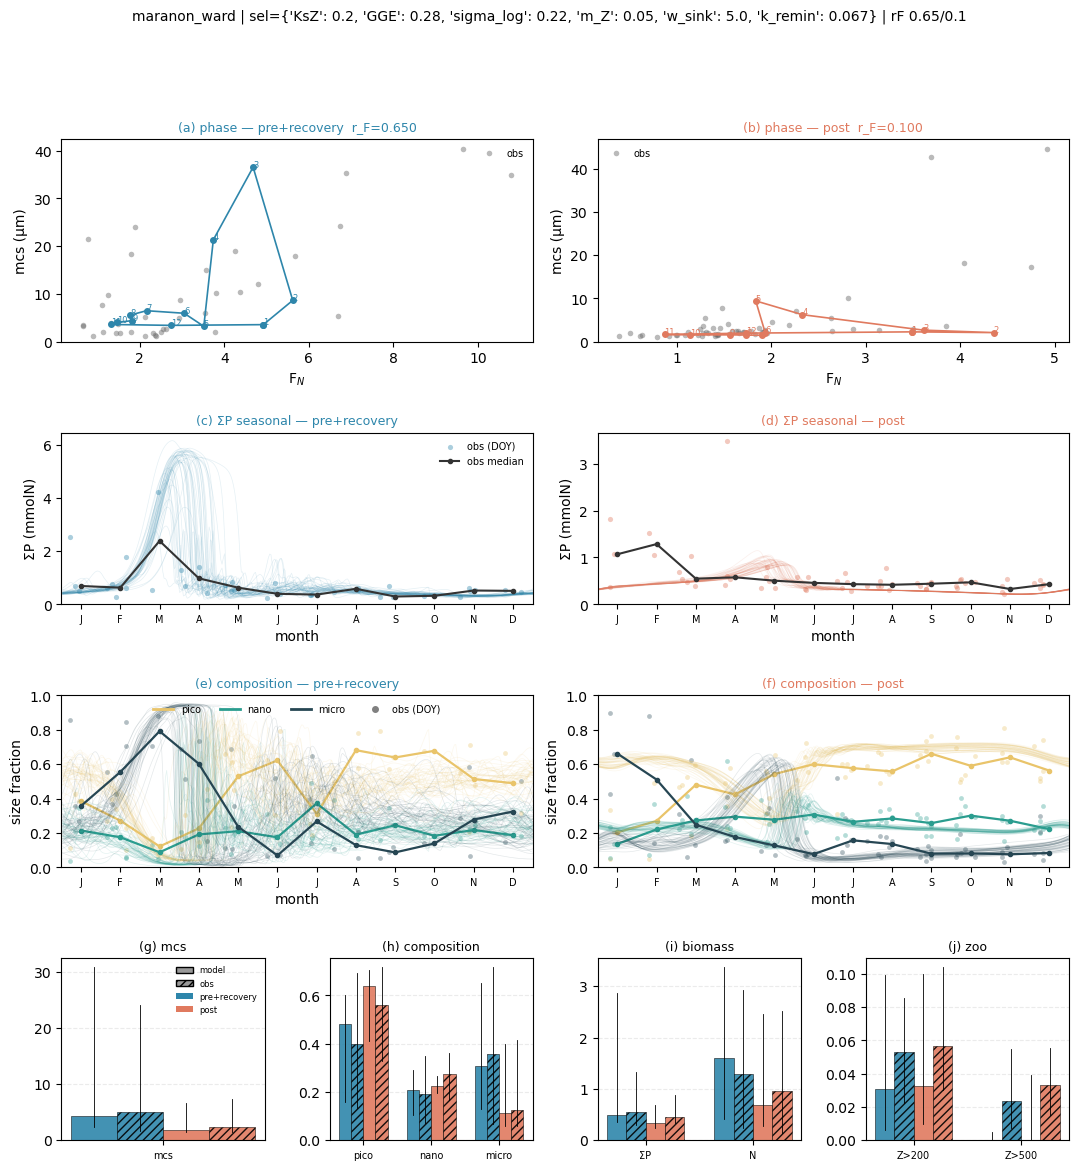

pre+recovery   squiggle  ΣP 0.288   micro 0.301   (HIGH = spaghetti)
post           squiggle  ΣP 0.051   micro 0.189   (HIGH = spaghetti)

##### pre+recovery  r_F=0.6 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.15  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.05  m_Zlin 0.05  r_F 0.6
  detritus: k_remin 0.067  w_sink 5.0  ->  L = 75 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.25 / export 0.25
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

##### pos

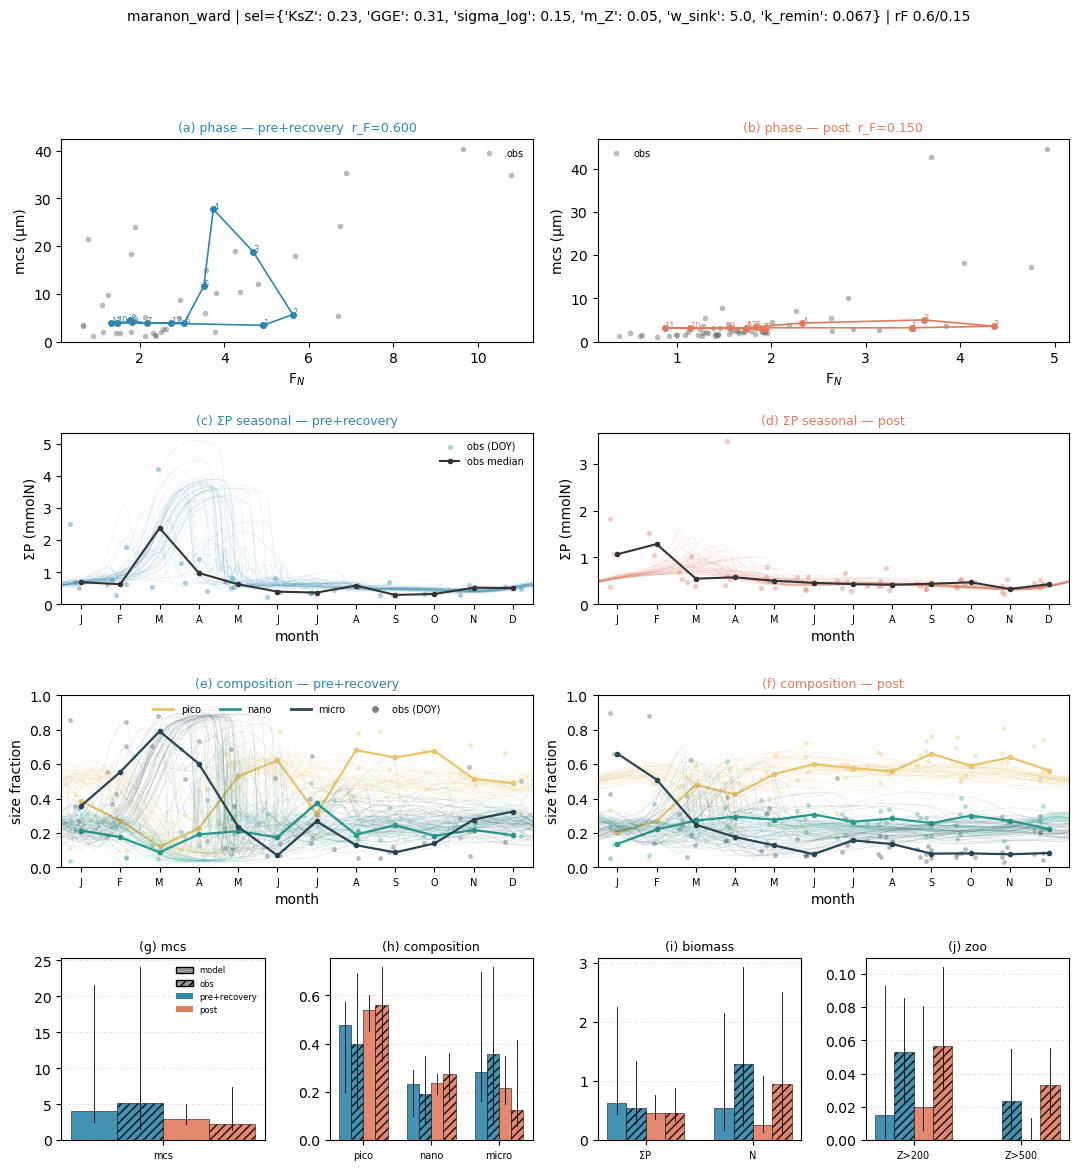

pre+recovery   squiggle  ΣP 0.286   micro 0.314   (HIGH = spaghetti)
post           squiggle  ΣP 0.106   micro 0.302   (HIGH = spaghetti)


In [12]:
runs,_ = fig4_overview(RP,RQ,0.55,0.10,sel={'KsZ':0.15,'GGE':0.25,'sigma_log':0.20,'m_Z':0.10,'w_sink':5.0,'k_remin':0.067}); squiggle_report(runs)  # A
runs,_ = fig4_overview(RP,RQ,0.65,0.10,sel={'KsZ':0.20,'GGE':0.28,'sigma_log':0.22,'m_Z':0.05,'w_sink':5.0,'k_remin':0.067}); squiggle_report(runs)  # B
runs,_ = fig4_overview(RP,RQ,0.60,0.15,sel={'KsZ':0.23,'GGE':0.31,'sigma_log':0.15,'m_Z':0.05,'w_sink':5.0,'k_remin':0.067}); squiggle_report(runs)  # C

In [13]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_grid2_pre_2026-06-29.pkl'); RQ=ssh.load_results('seasonal_grid2_post_2026-06-29.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; obs_m=ssh.build_obs_monthly(['pre+recovery','post']); _MO=np.arange(1,13)
log_oc={g:np.log10(obs_m[g].dropna(subset=['mcs']).groupby('mo')['mcs'].median().reindex(_MO).to_numpy()) for g in OBS}
oP,oQ=OBS['pre+recovery']['med'],OBS['post']['med']; CK=['KsZ','GGE','sigma_log','m_Z','w_sink','k_remin']
A=dict(KsZ=0.15,GGE=0.25,sigma_log=0.20,m_Z=0.10,w_sink=5.0,k_remin=0.067); ARFpre,ARFpost=0.55,0.10
def comp_e(r,o):
    ks=['mcs','pico','nano','micro']; e=[(r.get(k+'_med',np.nan)-o[k])/o[k] for k in ks if o.get(k)]
    return float(np.sqrt(np.nanmean(np.square(e))))
def brmse(r,g):
    c=np.asarray(r.get('clim_mcs',[np.nan]*12),float); return float(np.sqrt(np.nanmean((np.log10(c)-log_oc[g])**2)))
def rs(a,b): return (a-b)/a if abs(a)>1e-9 else np.nan
def kk(cfg,f): return tuple(round(cfg[k],4) for k in CK)+(round(f,3),)
Pidx={kk({k:p[k] for k in CK},p['fish']):p for p in RP.records}; Qidx={kk({k:q[k] for k in CK},q['fish']):q for q in RQ.records}
def met(cfg,rfp,rfq):
    p=Pidx.get(kk(cfg,rfp)); q=Qidx.get(kk(cfg,rfq))
    if not p or not q or p.get('has_nan') or q.get('has_nan'): return None
    return dict(comp=round(max(comp_e(p,oP),comp_e(q,oQ)),3), bloom=round(max(brmse(p,'pre+recovery'),brmse(q,'post')),3),
        squig=round(p.get('squiggle_sumP',np.nan),3), inv=round(q['Z200_med']-p['Z200_med'],4),
        Zpre=round(p['Z200_med'],4), Zpost=round(q['Z200_med'],4),
        shP=round(abs(rs(p['sumP_med'],q['sumP_med'])-rs(oP['sumP'],oQ['sumP'])),3),
        shN=round(abs(rs(p['N_med'],q['N_med'])-rs(oP['N'],oQ['N'])),3),
        pze=round(p.get('pze',np.nan),2), cvPre=round(p['cv_sumP'],2))
GRID={'KsZ':[0.15,0.20,0.23],'GGE':[0.25,0.28,0.31,0.33],'sigma_log':[0.15,0.18,0.20,0.22,0.25],'m_Z':[0.05,0.10]}
rows=[dict(axis='A (base)',val='', **met(A,ARFpre,ARFpost))]
for ax,vals in GRID.items():
    for v in vals:
        if abs(v-A[ax])<1e-9: continue
        m=met({**A,ax:v},ARFpre,ARFpost)
        if m: rows.append(dict(axis=ax,val=v,**m))
for ws,kr in [(5.0,0.04),(7.5,0.04)]:
    m=met({**A,'w_sink':ws,'k_remin':kr},ARFpre,ARFpost)
    if m: rows.append(dict(axis='detritus',val=f"L{ws/kr:.0f}",**m))
for v in [0.3,0.4,0.5,0.6,0.65]:
    m=met(A,v,ARFpost)
    if m: rows.append(dict(axis='rF_pre',val=v,**m))
for v in [0.15,0.20]:
    m=met(A,ARFpre,v)
    if m: rows.append(dict(axis='rF_post',val=v,**m))
print(f"OAT around A | obs Z200 {oP['Z200']:.3f}/{oQ['Z200']:.3f} (inv +{oQ['Z200']-oP['Z200']:.4f}) | obs relshift ΣP {rs(oP['sumP'],oQ['sumP']):.2f} N {rs(oP['N'],oQ['N']):.2f}\n")
print(pd.DataFrame(rows).to_string(index=False))

OAT around A | obs Z200 0.053/0.057 (inv +0.0035) | obs relshift ΣP 0.17 N 0.25

     axis   val  comp  bloom  squig     inv   Zpre  Zpost   shP   shN  pze  cvPre
 A (base)       0.078  0.460  0.494  0.0042 0.0173 0.0215 0.149 0.119 0.49   1.35
      KsZ   0.2 0.282  0.419  0.431 -0.0039 0.0152 0.0113 0.145 0.170 0.49   1.27
      KsZ  0.23 0.437  0.353  0.356 -0.0009 0.0133 0.0124 0.085 0.204 0.49   1.16
      GGE  0.28 0.189  0.497  0.492  0.0104 0.0241 0.0345 0.068 0.283 0.49   1.30
      GGE  0.31 0.237  0.511  0.254 -0.0030 0.0443 0.0413 0.141 0.434 0.48   0.70
      GGE  0.33 0.247  0.497  0.076 -0.0041 0.0541 0.0500 0.173 0.462 0.48   0.40
sigma_log  0.15 0.477  0.457  0.478  0.0054 0.0147 0.0201 0.082 0.064 0.49   1.12
sigma_log  0.18 0.330  0.389  0.559  0.0031 0.0149 0.0179 0.116 0.114 0.49   1.35
sigma_log  0.22 0.188  0.510  0.529  0.0073 0.0248 0.0321 0.103 0.191 0.49   1.40
sigma_log  0.25 0.495  0.371  0.644 -0.0018 0.0341 0.0323 0.114 0.264 0.48   1.34
      m_Z  0.05 0

In [14]:
import numpy as np, seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func
forc_obs = ssh.build_forcings(['pre+recovery','post'])
def _smooth(m,n=2): return _build_fourier_func(m,period=365.0,n_harmonics=n)(np.linspace(0,365,365))
def _char(m):
    s=_smooth(m); return float(s.mean()), float((s.max()-s.min())/2), int(np.argmax(s))
PFN_M,PFN_A,PHI=_char(forc_obs['post']['fn']); RFN_M,RFN_A,_=_char(forc_obs['pre+recovery']['fn'])
PDE_M,PDE_A,_=_char(forc_obs['post']['de']); RDE_M,RDE_A,_=_char(forc_obs['pre+recovery']['de'])
PT_M,PT_A,_=_char(forc_obs['post']['t']);    RT_M,RT_A,_=_char(forc_obs['pre+recovery']['t'])
MID=np.array([15,46,74,105,135,166,196,227,258,288,319,349])
def sinus(alpha):
    fn_m=PFN_M+alpha*(RFN_M-PFN_M); fn_a=PFN_A+alpha*(RFN_A-PFN_A)
    de_m=PDE_M+alpha*(RDE_M-PDE_M); de_a=PDE_A+alpha*(RDE_A-PDE_A)
    t_m =PT_M +alpha*(RT_M -PT_M);  t_a =PT_A +alpha*(RT_A -PT_A)
    c=np.cos(2*np.pi*(MID-PHI)/365)
    return {'fn':np.maximum(fn_m+fn_a*c,0.01),'de':np.maximum(de_m-de_a*c,5.0),'t':t_m-t_a*c}
spec=ssh.allometry('maranon_ward')
GRZ={'KsZ':0.15,'sigma_log':0.20}
IVO={'GrazingRouter':{'gge':0.25}, 'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0}, 'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0}, 'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
RF_LOW, RF_HIGH = 0.10, 0.55                       # A's post / pre r_F
CORNERS={'post  (α0,rF.10)':(0.0,RF_LOW), 'BUonly(α1,rF.10)':(1.0,RF_LOW),
         'TDonly(α0,rF.55)':(0.0,RF_HIGH),'pre+rec(α1,rF.55)':(1.0,RF_HIGH)}
out={}
print(f"{'corner':18s} {'mcs':>6} {'ΣP':>6} {'Z200':>7} {'micro':>6} {'N':>6} {'cv':>5} nan")
for tag,(a,rf) in CORNERS.items():
    c=ssh.run_one(spec, sinus(a), fish_rate=rf, years=60, spinup=15, mP=0.0015, m_Z=0.10,
                  grazing=GRZ, iv_overrides=IVO, n_harmonics=3, routed=True)
    out[tag]=c
    print(f"{tag:18s} {c['mcs_med']:6.2f} {c['sumP']:6.2f} {c['Z200_med']:7.4f} {c['micro_med']:6.2f} "
          f"{c['N_med']:6.2f} {c['cv_sumP']:5.2f} {c['has_nan']}")

corner                mcs     ΣP    Z200  micro      N    cv nan
post  (α0,rF.10)     2.56   0.43  0.0274   0.18   1.01  0.52 False
BUonly(α1,rF.10)     2.42   0.98  0.0333   0.13   1.65  1.45 False
TDonly(α0,rF.55)     3.59   0.74  0.0107   0.26   0.66  1.28 False
pre+rec(α1,rF.55)    4.99   1.25  0.0154   0.34   1.12  1.42 False


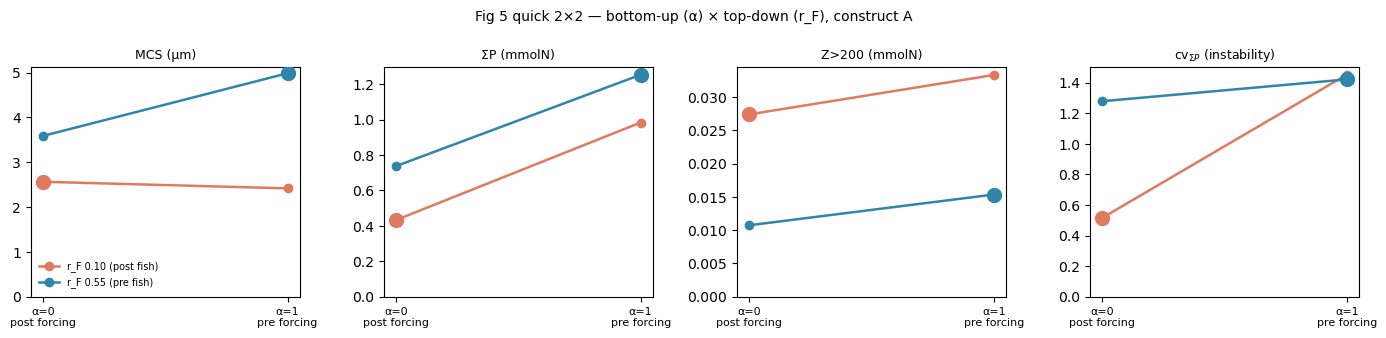

In [15]:
import matplotlib.pyplot as plt
M=[('mcs_med','MCS (µm)'),('sumP','ΣP (mmolN)'),('Z200_med','Z>200 (mmolN)'),('cv_sumP','cv$_{ΣP}$ (instability)')]
CP,CR='#E07A5F','#2E86AB'
fig,ax=plt.subplots(1,4,figsize=(14,3.4))
for a,(k,lab) in zip(ax,M):
    lo=[out['post  (α0,rF.10)'][k], out['BUonly(α1,rF.10)'][k]]    # r_F 0.10 across α
    hi=[out['TDonly(α0,rF.55)'][k], out['pre+rec(α1,rF.55)'][k]]   # r_F 0.55 across α
    a.plot([0,1],lo,'-o',color=CP,lw=1.8,label='r_F 0.10 (post fish)')
    a.plot([0,1],hi,'-o',color=CR,lw=1.8,label='r_F 0.55 (pre fish)')
    a.plot(0,lo[0],'o',ms=10,color=CP,zorder=5); a.plot(1,hi[1],'o',ms=10,color=CR,zorder=5)  # era anchors
    a.set_xticks([0,1]); a.set_xticklabels(['α=0\npost forcing','α=1\npre forcing'],fontsize=8)
    a.set_title(lab,fontsize=9); a.set_ylim(bottom=0)
ax[0].legend(fontsize=7,frameon=False)
fig.suptitle('Fig 5 quick 2×2 — bottom-up (α) × top-down (r_F), construct A',fontsize=10)
fig.tight_layout(); plt.show()

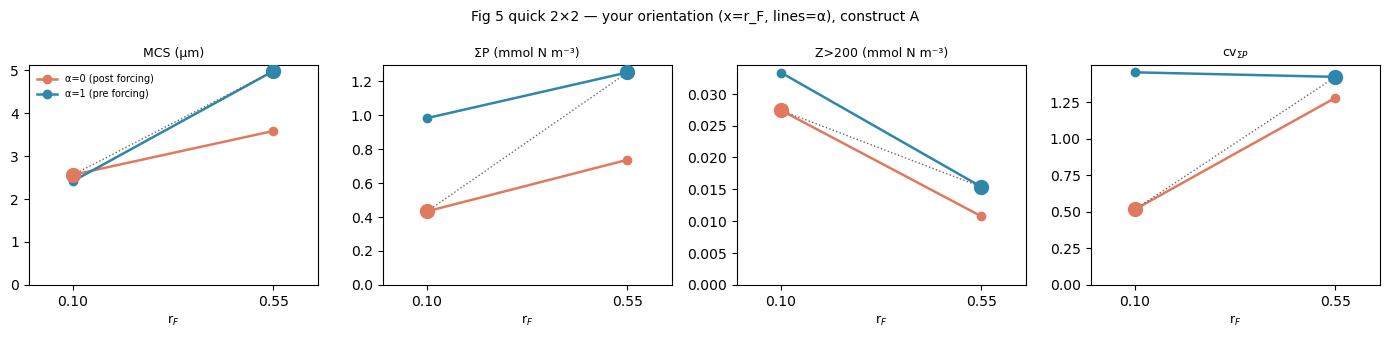

In [16]:
import matplotlib.pyplot as plt
M=[('mcs_med','MCS (µm)'),('sumP','ΣP (mmol N m⁻³)'),('Z200_med','Z>200 (mmol N m⁻³)'),('cv_sumP','cv$_{ΣP}$')]
C_POST,C_PRE='#E07A5F','#2E86AB'   # α=0 post forcing / α=1 pre forcing — your convention
RF=[0.10,0.55]
fig,ax=plt.subplots(1,4,figsize=(14,3.4))
for a,(k,lab) in zip(ax,M):
    a0=[out['post  (α0,rF.10)'][k], out['TDonly(α0,rF.55)'][k]]    # α=0 across r_F
    a1=[out['BUonly(α1,rF.10)'][k], out['pre+rec(α1,rF.55)'][k]]   # α=1 across r_F
    a.plot(RF,a0,'-o',color=C_POST,lw=1.8,label='α=0 (post forcing)')
    a.plot(RF,a1,'-o',color=C_PRE, lw=1.8,label='α=1 (pre forcing)')
    a.plot([0.10,0.55],[a0[0],a1[1]],ls=':',color='0.4',lw=1.0)    # era diagonal post→pre
    a.plot(0.10,a0[0],'o',ms=10,color=C_POST,zorder=5); a.plot(0.55,a1[1],'o',ms=10,color=C_PRE,zorder=5)
    a.set_xlim(0,0.65); a.set_xticks([0.10,0.55]); a.set_xlabel('r$_F$',fontsize=9)
    a.set_title(lab,fontsize=9); a.set_ylim(bottom=0)
ax[0].legend(fontsize=7,frameon=False); fig.suptitle('Fig 5 quick 2×2 — your orientation (x=r_F, lines=α), construct A',fontsize=10)
fig.tight_layout(); plt.show()


=== A grounded fish N0.50 (D0.25/X0.25) ===
  MCS    α0 2.564->3.587 | α1 2.417->4.987 | α-sep lo -0.147 hi +1.400
  ΣP     α0 0.433->0.737 | α1 0.984->1.253 | α-sep lo +0.551 hi +0.516
  Z>200  α0 0.027->0.011 | α1 0.033->0.015 | α-sep lo +0.006 hi +0.005
  cv     α0 0.516->1.279 | α1 1.453->1.422 | α-sep lo +0.937 hi +0.143

=== old-style fish: pure export N0 (X1.0) ===
  MCS    α0 2.127->3.931 | α1 2.657->4.172 | α-sep lo +0.530 hi +0.241
  ΣP     α0 0.407->0.612 | α1 0.943->0.913 | α-sep lo +0.536 hi +0.301
  Z>200  α0 0.023->0.006 | α1 0.043->0.014 | α-sep lo +0.020 hi +0.008
  cv     α0 0.676->1.041 | α1 1.387->1.304 | α-sep lo +0.710 hi +0.263


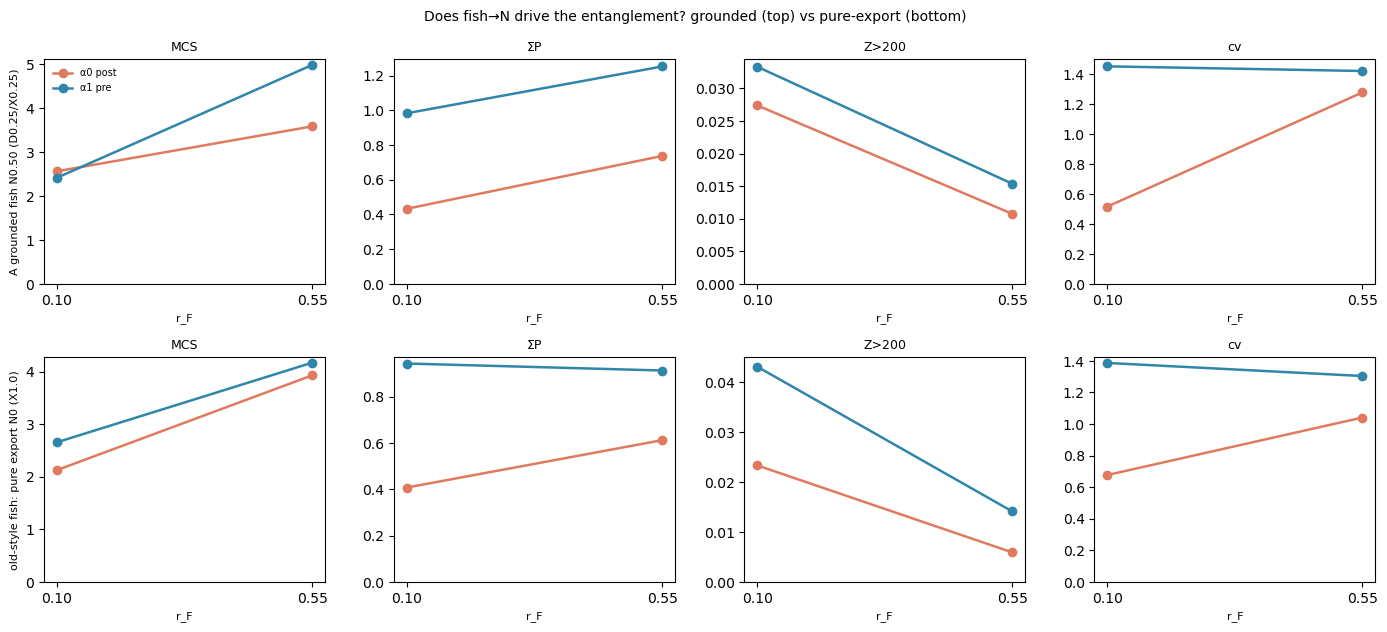

In [17]:
import numpy as np, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
FISH={'A grounded fish N0.50 (D0.25/X0.25)':{'frac_D':0.25,'frac_export':0.25},
      'old-style fish: pure export N0 (X1.0)':{'frac_D':0.0,'frac_export':1.0}}
BASE={'GrazingRouter':{'gge':0.25},'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
      'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
GRZ={'KsZ':0.15,'sigma_log':0.20}; CRN={'post':(0.0,0.10),'BUonly':(1.0,0.10),'TDonly':(0.0,0.55),'pre':(1.0,0.55)}
def corners(fr):
    ivo=dict(BASE); ivo['FishGrazing']=fr
    return {t:ssh.run_one(spec,sinus(a),fish_rate=rf,years=60,spinup=15,mP=0.0015,m_Z=0.10,
            grazing=GRZ,iv_overrides=ivo,n_harmonics=3,routed=True) for t,(a,rf) in CRN.items()}
RES={n:corners(fr) for n,fr in FISH.items()}
M=[('mcs_med','MCS'),('sumP','ΣP'),('Z200_med','Z>200'),('cv_sumP','cv')]; CP,CR='#E07A5F','#2E86AB'; RF=[0.10,0.55]
fig,ax=plt.subplots(2,4,figsize=(14,6.4))
for ri,(name,o) in enumerate(RES.items()):
    print(f"\n=== {name} ===")
    for ci,(k,lab) in enumerate(M):
        a0=[o['post'][k],o['TDonly'][k]]; a1=[o['BUonly'][k],o['pre'][k]]
        ax[ri,ci].plot(RF,a0,'-o',color=CP,lw=1.8,label='α0 post'); ax[ri,ci].plot(RF,a1,'-o',color=CR,lw=1.8,label='α1 pre')
        ax[ri,ci].set_xticks(RF); ax[ri,ci].set_xlabel('r_F',fontsize=8); ax[ri,ci].set_ylim(bottom=0); ax[ri,ci].set_title(lab,fontsize=9)
        print(f"  {lab:6s} α0 {a0[0]:.3f}->{a0[1]:.3f} | α1 {a1[0]:.3f}->{a1[1]:.3f} | α-sep lo {a1[0]-a0[0]:+.3f} hi {a1[1]-a0[1]:+.3f}")
    ax[ri,0].set_ylabel(name,fontsize=8)
ax[0,0].legend(fontsize=7,frameon=False)
fig.suptitle('Does fish→N drive the entanglement? grounded (top) vs pure-export (bottom)',fontsize=10); fig.tight_layout(); plt.show()

C at own anchors (post α0/rF0.15, pre α1/rF0.60):
  MCS    α0 2.874->3.298 | α1 2.449->3.885 | α-sep lo -0.425 hi +0.586
  ΣP     α0 0.517->0.677 | α1 0.673->1.026 | α-sep lo +0.156 hi +0.350
  Z>200  α0 0.024->0.000 | α1 0.053->0.015 | α-sep lo +0.029 hi +0.015
  cv     α0 0.372->0.678 | α1 0.606->0.994 | α-sep lo +0.234 hi +0.316


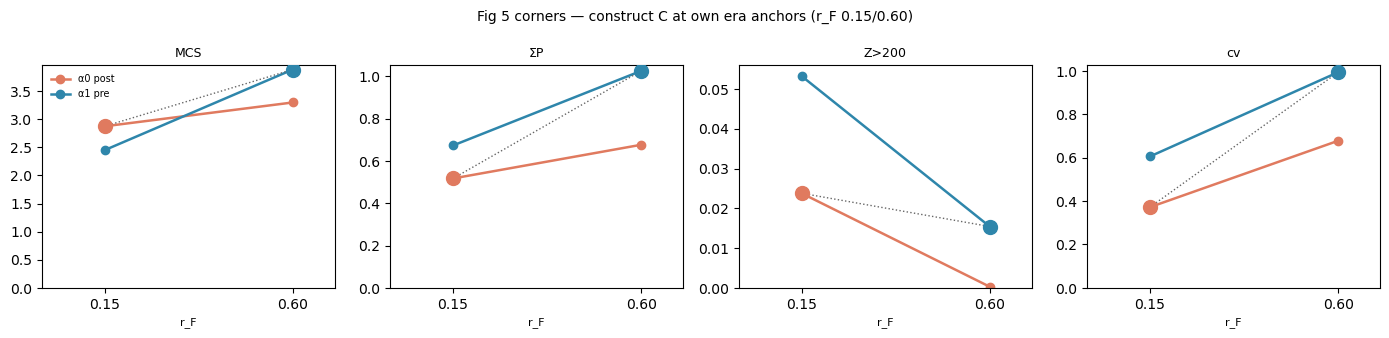

In [18]:
import numpy as np, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
GRZ={'KsZ':0.23,'sigma_log':0.15}
IVO={'GrazingRouter':{'gge':0.31},'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
RF_LO,RF_HI=0.15,0.60
CRN={'post':(0.0,RF_LO),'BUonly':(1.0,RF_LO),'TDonly':(0.0,RF_HI),'pre':(1.0,RF_HI)}
o={t:ssh.run_one(spec,sinus(a),fish_rate=rf,years=60,spinup=15,mP=0.0015,m_Z=0.05,
   grazing=GRZ,iv_overrides=IVO,n_harmonics=3,routed=True) for t,(a,rf) in CRN.items()}
M=[('mcs_med','MCS'),('sumP','ΣP'),('Z200_med','Z>200'),('cv_sumP','cv')]; CP,CR='#E07A5F','#2E86AB'; RF=[RF_LO,RF_HI]
fig,ax=plt.subplots(1,4,figsize=(14,3.4))
print("C at own anchors (post α0/rF0.15, pre α1/rF0.60):")
for a,(k,lab) in zip(ax,M):
    a0=[o['post'][k],o['TDonly'][k]]; a1=[o['BUonly'][k],o['pre'][k]]
    a.plot(RF,a0,'-o',color=CP,lw=1.8,label='α0 post'); a.plot(RF,a1,'-o',color=CR,lw=1.8,label='α1 pre')
    a.plot([RF_LO,RF_HI],[a0[0],a1[1]],ls=':',color='0.4',lw=1.0)
    a.plot(RF_LO,a0[0],'o',ms=10,color=CP,zorder=5); a.plot(RF_HI,a1[1],'o',ms=10,color=CR,zorder=5)
    a.set_xlim(0,0.7); a.set_xticks(RF); a.set_xlabel('r_F',fontsize=8); a.set_ylim(bottom=0); a.set_title(lab,fontsize=9)
    print(f"  {lab:6s} α0 {a0[0]:.3f}->{a0[1]:.3f} | α1 {a1[0]:.3f}->{a1[1]:.3f} | α-sep lo {a1[0]-a0[0]:+.3f} hi {a1[1]-a0[1]:+.3f}")
ax[0].legend(fontsize=7,frameon=False)
fig.suptitle('Fig 5 corners — construct C at own era anchors (r_F 0.15/0.60)',fontsize=10); fig.tight_layout(); plt.show()

B at own anchors (post α0/rF0.10, pre α1/rF0.65):
  MCS    α0 1.798->3.533 | α1 1.564->4.199 | α-sep lo -0.234 hi +0.667
  ΣP     α0 0.393->0.606 | α1 0.690->1.008 | α-sep lo +0.296 hi +0.401
  Z>200  α0 0.043->0.002 | α1 0.028->0.028 | α-sep lo -0.015 hi +0.026
  cv     α0 0.498->1.040 | α1 1.169->1.395 | α-sep lo +0.671 hi +0.355


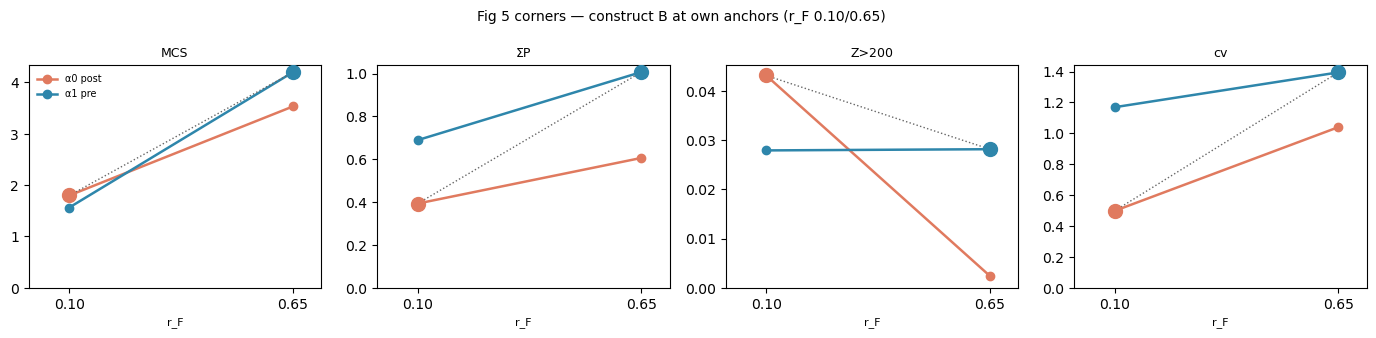

In [19]:
import numpy as np, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
GRZ={'KsZ':0.20,'sigma_log':0.22}
IVO={'GrazingRouter':{'gge':0.28},'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
RF_LO,RF_HI=0.10,0.65
CRN={'post':(0.0,RF_LO),'BUonly':(1.0,RF_LO),'TDonly':(0.0,RF_HI),'pre':(1.0,RF_HI)}
o={t:ssh.run_one(spec,sinus(a),fish_rate=rf,years=60,spinup=15,mP=0.0015,m_Z=0.05,
   grazing=GRZ,iv_overrides=IVO,n_harmonics=3,routed=True) for t,(a,rf) in CRN.items()}
M=[('mcs_med','MCS'),('sumP','ΣP'),('Z200_med','Z>200'),('cv_sumP','cv')]; CP,CR='#E07A5F','#2E86AB'; RF=[RF_LO,RF_HI]
fig,ax=plt.subplots(1,4,figsize=(14,3.4)); print("B at own anchors (post α0/rF0.10, pre α1/rF0.65):")
for a,(k,lab) in zip(ax,M):
    a0=[o['post'][k],o['TDonly'][k]]; a1=[o['BUonly'][k],o['pre'][k]]
    a.plot(RF,a0,'-o',color=CP,lw=1.8,label='α0 post'); a.plot(RF,a1,'-o',color=CR,lw=1.8,label='α1 pre')
    a.plot([RF_LO,RF_HI],[a0[0],a1[1]],ls=':',color='0.4',lw=1.0)
    a.plot(RF_LO,a0[0],'o',ms=10,color=CP,zorder=5); a.plot(RF_HI,a1[1],'o',ms=10,color=CR,zorder=5)
    a.set_xlim(0,0.72); a.set_xticks(RF); a.set_xlabel('r_F',fontsize=8); a.set_ylim(bottom=0); a.set_title(lab,fontsize=9)
    print(f"  {lab:6s} α0 {a0[0]:.3f}->{a0[1]:.3f} | α1 {a1[0]:.3f}->{a1[1]:.3f} | α-sep lo {a1[0]-a0[0]:+.3f} hi {a1[1]-a0[1]:+.3f}")
ax[0].legend(fontsize=7,frameon=False); fig.suptitle('Fig 5 corners — construct B at own anchors (r_F 0.10/0.65)',fontsize=10); fig.tight_layout(); plt.show()

In [20]:
import numpy as np, seasonal_scan_harness as ssh
F=ssh.build_forcings(['pre+recovery','post']); oP=ssh.build_obs_targets(['pre+recovery'])['pre+recovery']['med']
spec=ssh.allometry('maranon_ward'); GRZ={'KsZ':0.15,'sigma_log':0.20}
IVO={'GrazingRouter':{'gge':0.25},'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
def comp_e(c,o):
    e=[(c.get(k+'_med',np.nan)-o[k])/o[k] for k in ['mcs','pico','nano','micro']]; return float(np.sqrt(np.nanmean(np.square(e))))
print("A pre era, obs-Fourier:")
for rf in (0.50,0.55):
    c=ssh.run_one(spec,F['pre+recovery'],fish_rate=rf,years=60,spinup=15,mP=0.0015,m_Z=0.10,
                  grazing=GRZ,iv_overrides=IVO,n_harmonics=3,routed=True)
    print(f"  r_F {rf}: comp {comp_e(c,oP):.3f}  mcs {c['mcs_med']:.2f}  micro {c['micro_med']:.2f}  "
          f"Zpre {c['Z200_med']:.4f}  squig {c.get('squiggle_sumP',np.nan):.3f}  cv {c['cv_sumP']:.2f}")

A pre era, obs-Fourier:
  r_F 0.5: comp 0.142  mcs 4.30  micro 0.30  Zpre 0.0182  squig 0.589  cv 1.40
  r_F 0.55: comp 0.097  mcs 4.69  micro 0.33  Zpre 0.0162  squig 0.495  cv 1.36
